# Repo 1 : Data & Features

**Objectif** : Préparer les données brutes pour l'analyse et la modélisation.  
- Chargement du dataset bancaire.
- Exploration rapide.
- Nettoyage & standardisation.
- Feature engineering.
- Export des datasets segmentés (profil, campagne, finance, macro).

**Données** : `bank-additional-full.csv` (fichier CSV fourni).



2. Imports & setup


In [1]:
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Créer dossier outputs
PROJECT_ROOT = Path(os.getcwd())
OUT_DIR = PROJECT_ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Outputs folder:', OUT_DIR)


Project root: c:\Users\ahmed\OneDrive\Desktop\projet_data
Outputs folder: c:\Users\ahmed\OneDrive\Desktop\projet_data\outputs


3. Chargement des données

In [3]:
data_path = PROJECT_ROOT / "data/bank-additional-full.csv"
df = pd.read_csv(data_path, sep=None, engine='python')
df['id'] = df.index + 1  # Ajouter une colonne ID

# Aperçu
display(df.head())
print(df.info())
print(df.describe())


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,id
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,3
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,4
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

4. Résumé des colonnes

In [4]:
# Générer un tableau de synthèse des colonnes
cols_summary = [
    {'col': 'age', 'dtype': 'int', 'utilité': 'Distribution des âges', 'importance': 'Forte', 'remarque': 'Vérifier présence d’âges extrêmes'},
    {'col': 'job', 'dtype': 'cat', 'utilité': 'Répartition par profession', 'importance': 'Moyenne à forte', 'remarque': 'Encodage catégoriel nécessaire'},
    {'col': 'marital', 'dtype': 'cat', 'utilité': 'Statut marital, analyse socio-démographique', 'importance': 'Moyenne', 'remarque': 'Regrouper éventuellement en couples / célibataires'},
    {'col': 'education', 'dtype': 'cat', 'utilité': 'Niveau d’éducation des clients', 'importance': 'Moyenne', 'remarque': 'Harmoniser les libellés, gérer les “unknown”'},
    {'col': 'default', 'dtype': 'cat', 'utilité': 'Historique de défaut de paiement', 'importance': 'Forte', 'remarque': 'Traiter valeurs inconnues (“unknown”)'},
    {'col': 'housing', 'dtype': 'cat', 'utilité': 'Possession d’un crédit immobilier', 'importance': 'Moyenne', 'remarque': 'Encodage nécessaire'},
    {'col': 'loan', 'dtype': 'cat', 'utilité': 'Possession d’un prêt personnel', 'importance': 'Moyenne', 'remarque': 'Encodage nécessaire'},
    {'col': 'contact', 'dtype': 'cat', 'utilité': 'Canal de communication', 'importance': 'Faible à moyenne', 'remarque': 'Peut aider à comprendre efficacité des campagnes'},
    {'col': 'month', 'dtype': 'cat', 'utilité': 'Mois du dernier contact', 'importance': 'Faible à moyenne', 'remarque': 'Encodage cyclique possible pour capturer saisonnalité'},
    {'col': 'day_of_week', 'dtype': 'cat', 'utilité': 'Jour de la semaine du dernier contact', 'importance': 'Faible à moyenne', 'remarque': 'Encodage cyclique possible'},
    {'col': 'duration', 'dtype': 'int', 'utilité': 'Durée du dernier contact (en secondes)', 'importance': 'Très forte', 'remarque': 'Attention : fuite de donnée possible si utilisé tel quel'},
    {'col': 'campaign', 'dtype': 'int', 'utilité': 'Nombre de contacts lors de la campagne', 'importance': 'Moyenne', 'remarque': 'Vérifier valeurs extrêmes'},
    {'col': 'pdays', 'dtype': 'int', 'utilité': 'Jours depuis le dernier contact précédent', 'importance': 'Moyenne', 'remarque': '999 indique “pas de contact précédent”, à gérer'},
    {'col': 'previous', 'dtype': 'int', 'utilité': 'Nombre de contacts antérieurs', 'importance': 'Moyenne', 'remarque': 'Utile pour le comportement client'},
    {'col': 'poutcome', 'dtype': 'cat', 'utilité': 'Résultat de la campagne précédente', 'importance': 'Forte', 'remarque': 'Catégorie clé (“success”, “failure”, “other”)'},
    {'col': 'emp.var.rate', 'dtype': 'float', 'utilité': 'Taux de variation de l’emploi', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie, influence possible sur souscription'},
    {'col': 'cons.price.idx', 'dtype': 'float', 'utilité': 'Indice des prix à la consommation', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie'},
    {'col': 'cons.conf.idx', 'dtype': 'float', 'utilité': 'Indice de confiance des consommateurs', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie'},
    {'col': 'euribor3m', 'dtype': 'float', 'utilité': 'Taux Euribor 3 mois', 'importance': 'Moyenne', 'remarque': 'Influence les décisions financières'},
    {'col': 'nr.employed', 'dtype': 'float', 'utilité': 'Nombre d’employés', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie, tendance générale'},
    {'col': 'y', 'dtype': 'cat', 'utilité': 'Variable cible : souscription oui/non', 'importance': 'Très forte', 'remarque': 'À prédire, encoder “yes”=1 / “no”=0'}
]

cols_df = pd.DataFrame(cols_summary)
cols_df.to_csv(OUT_DIR / 'columns_summary.csv', index=False)
display(cols_df)


,col,dtype,utilité,importance,remarque
0,age,int,Distribution des âges,Forte,Vérifier présence d’âges extrêmes
1,job,cat,Répartition par profession,Moyenne à forte,Encodage catégoriel nécessaire
2,marital,cat,"Statut marital, analyse socio-démographique",Moyenne,Regrouper éventuellement en couples / célibata...
3,education,cat,Niveau d’éducation des clients,Moyenne,"Harmoniser les libellés, gérer les “unknown”"
4,default,cat,Historique de défaut de paiement,Forte,Traiter valeurs inconnues (“unknown”)
5,housing,cat,Possession d’un crédit immobilier,Moyenne,Encodage nécessaire
6,loan,cat,Possession d’un prêt personnel,Moyenne,Encodage nécessaire
7,contact,cat,Canal de communication,Faible à moyenne,Peut aider à comprendre efficacité des campagnes
8,month,cat,Mois du dernier contact,Faible à moyenne,Encodage cyclique possible pour capturer saiso...
9,day_of_week,cat,Jour de la semaine du dernier contact,Faible à moyenne,Encodage cyclique possible


5. Prétraitement

In [5]:
def standardize_missing(df):
    df = df.copy()
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].replace(['unknown','nonexistent'], np.nan)
    return df

df_clean = standardize_missing(df)

# Vérifier les missing values
display(df_clean.isna().sum().sort_values(ascending=False).head(10))


poutcome     35563
default       8597
education     1731
housing        990
loan           990
job            330
marital         80
age              0
month            0
contact          0
dtype: int64

6. Découpage par groupes de colonnes

In [7]:
profil_cols = ['id','age','job','marital','education','default','housing','loan']
campagne_cols = ['id','contact','month','day_of_week','duration','campaign','pdays','previous','poutcome','y']
macro_cols = ['id','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

df_profil = df_clean[profil_cols].copy()
df_campagne = df_clean[campagne_cols].copy()
df_macro = df_clean[macro_cols].copy()

# Export CSVs
df_profil.to_csv(OUT_DIR / 'profil_cols.csv', index=False)
df_campagne.to_csv(OUT_DIR / 'campagne_cols.csv', index=False)
df_macro.to_csv(OUT_DIR / 'macro_cols.csv', index=False)
print("CSV files exported to", OUT_DIR)

CSV files exported to c:\Users\ahmed\OneDrive\Desktop\projet_data\outputs


7. Feature Engineering

In [8]:
df_fe = df_clean.copy()

# Binning âge
age_bins = [0, 25, 35, 50, 65, 120]
age_labels = ['<25','25-34','35-49','50-64','65+']
df_fe['age_bin'] = pd.cut(df_fe['age'], bins=age_bins, labels=age_labels, include_lowest=True)

# pdays
df_fe['pdays_never_contacted'] = (df_fe['pdays'] == 999).astype(int)
df_fe['pdays_since'] = df_fe['pdays'].replace(999, np.nan)

# log duration
df_fe['duration_log1p'] = np.log1p(df_fe['duration'])

# Mois → trimestre → saison
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_fe['month_num'] = df_fe['month'].map(month_map)
df_fe['quarter'] = pd.to_datetime(df_fe['month_num'], format='%m', errors='coerce').dt.quarter
df_fe['season'] = df_fe['quarter'].map({1:'winter', 2:'spring', 3:'summer', 4:'autumn'})

# Interaction simple : jeune + appel court
df_fe['young_short_call'] = ((df_fe['age'] < 35) & (df_fe['duration'] < df_fe['duration'].median())).astype(int)

# Encodage ordinal éducation
edu_order = ['illiterate','basic.4y','basic.6y','basic.9y','high.school','university.degree','professional.course']
df_fe['education_ord'] = df_fe['education'].astype(pd.CategoricalDtype(categories=edu_order, ordered=True)).cat.codes.replace(-1,np.nan)

# Variable cible binaire
df_fe['y_bin'] = df_fe['y'].map({'yes':1,'no':0})

# Export final
df_fe.to_csv(OUT_DIR / 'up_data.csv', index=False)
display(df_fe.head())


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,age_bin,pdays_never_contacted,pdays_since,duration_log1p,month_num,quarter,season,young_short_call,education_ord,y_bin
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,50-64,1,NaN,5.568345,5,2,spring,0,1.0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,50-64,1,NaN,5.010635,5,2,spring,0,4.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,35-49,1,NaN,5.424950,5,2,spring,0,4.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,35-49,1,NaN,5.023881,5,2,spring,0,2.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,50-64,1,NaN,5.730100,5,2,spring,0,4.0,0


8. Visualisation Exploratoire (Business Understanding)

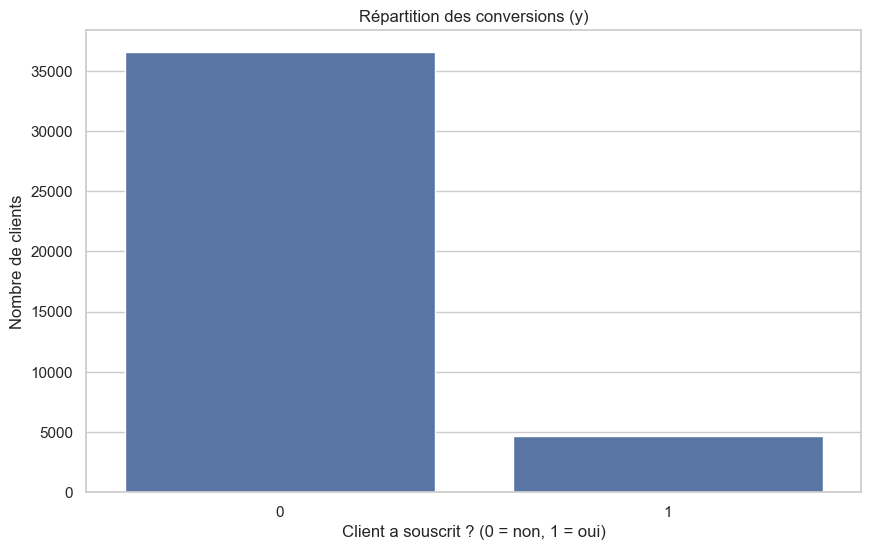

In [12]:
# 1. Répartition cible (conversion)
dt = df_fe.copy()
plt.figure()
sns.countplot(data=dt, x='y_bin')
plt.title("Répartition des conversions (y)")
plt.xlabel("Client a souscrit ? (0 = non, 1 = oui)")
plt.ylabel("Nombre de clients")
plt.savefig(OUT_DIR / "Répartition_des_conversions_(y).png", dpi=300, bbox_inches='tight')
plt.show()


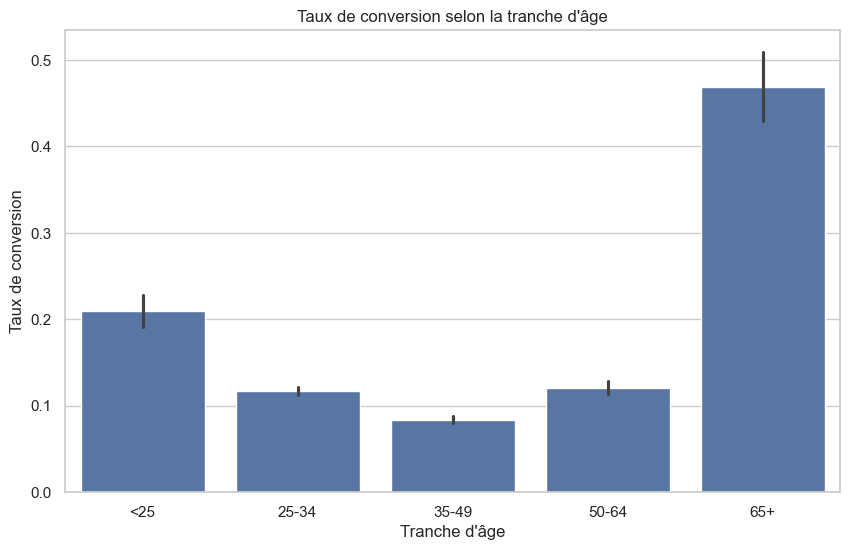

In [18]:
# 2. Taux de conversion par tranche d'âge
plt.figure()
sns.barplot(
    data=dt,
    x='age_bin',
    y='y_bin',
    estimator='mean',
    order= ['<25','25-34','35-49','50-64','65+']
)
plt.title("Taux de conversion selon la tranche d'âge")
plt.ylabel("Taux de conversion")
plt.xlabel("Tranche d'âge")
plt.savefig(OUT_DIR / "Taux_de_conversion_selon_la_tranche_age.png", dpi=300, bbox_inches='tight')
plt.show()


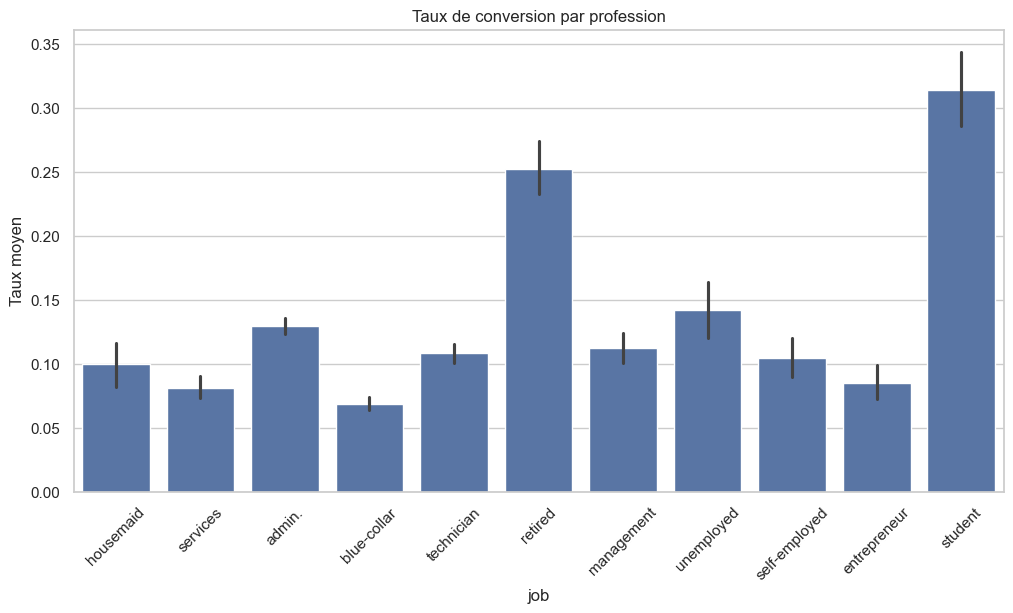

In [19]:
# 3. Taux de conversion par profession
plt.figure(figsize=(12,6))
sns.barplot(
    data=dt,
    x='job',
    y='y_bin',
    estimator='mean'
)
plt.title("Taux de conversion par profession")
plt.xticks(rotation=45)
plt.ylabel("Taux moyen")
plt.savefig(OUT_DIR / "Taux de conversion par profession.png", dpi=300, bbox_inches='tight')
plt.show()

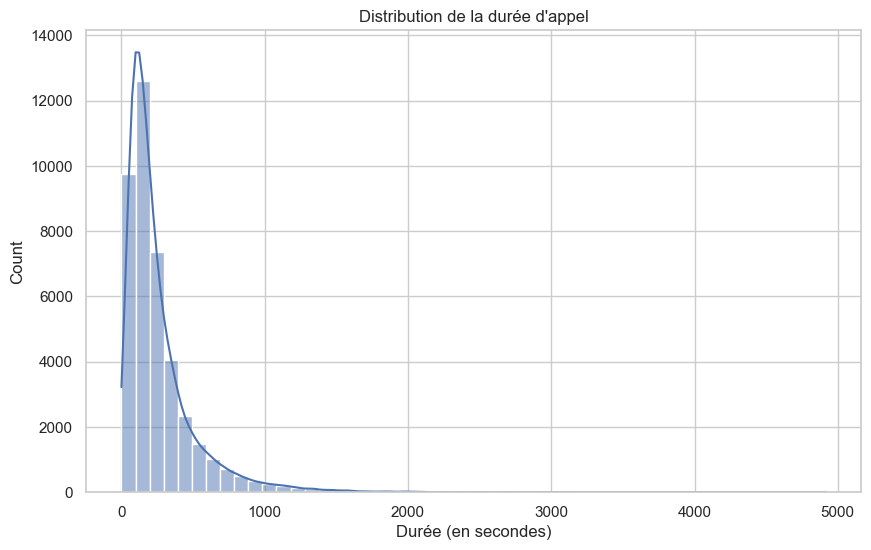

In [ ]:
# 4. Durée d'appel : distribution
plt.figure()
sns.histplot(dt['duration'], bins=50, kde=True)     
plt.title("Distribution de la durée d'appel")
plt.xlabel("Durée (en secondes)")
plt.savefig(OUT_DIR / "Distribution_de_la_durée_d'appel.png", dpi=300, bbox_inches='tight')
plt.show()


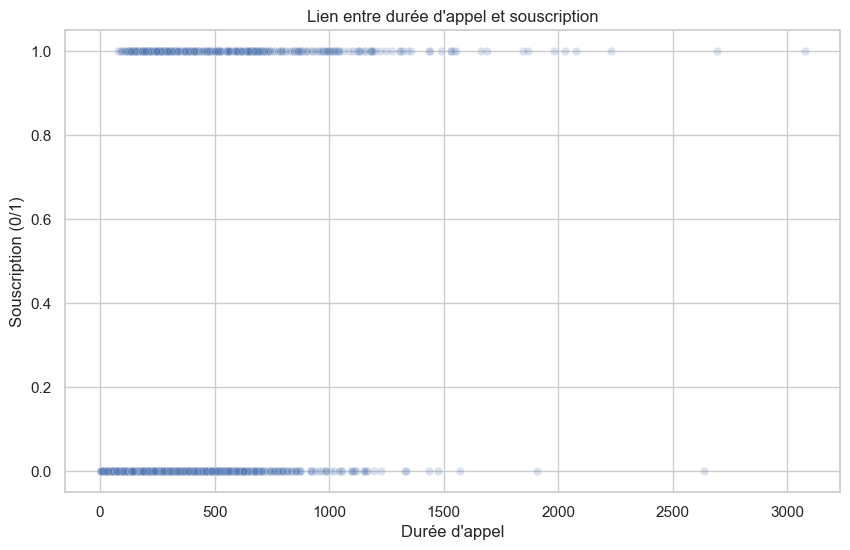

In [24]:
# 5. Relation durée vs probabilité
plt.figure()
sns.scatterplot(
    data=dt.sample(3000, random_state=123),
    x='duration',
    y='y_bin',
    alpha=0.2
)
plt.title("Lien entre durée d'appel et souscription")
plt.ylabel("Souscription (0/1)")
plt.xlabel("Durée d'appel")
plt.savefig(OUT_DIR / "Lien entre durée d'appel et souscription.png", dpi=300, bbox_inches='tight')
plt.show()


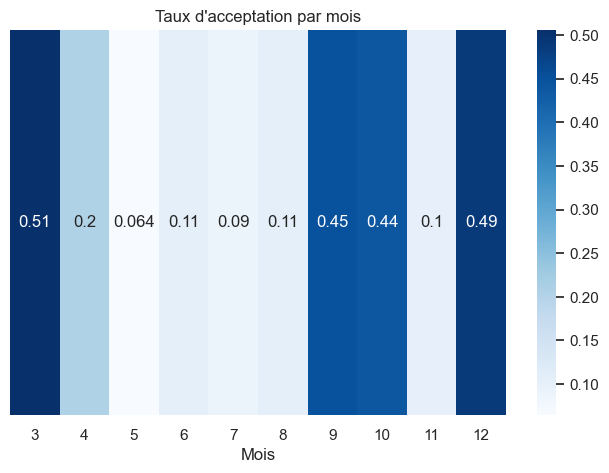

In [27]:
# 6. Conversion par mois de campagne
tmp = dt.groupby(['month_num'])['y_bin'].mean()

plt.figure(figsize=(8,5))
sns.heatmap(tmp.to_frame().T, annot=True, cmap="Blues")
plt.title("Taux d'acceptation par mois")
plt.yticks([])
plt.xlabel("Mois")
plt.savefig(OUT_DIR / "Taux d'acceptation par mois.png", dpi=300, bbox_inches='tight')
plt.show()


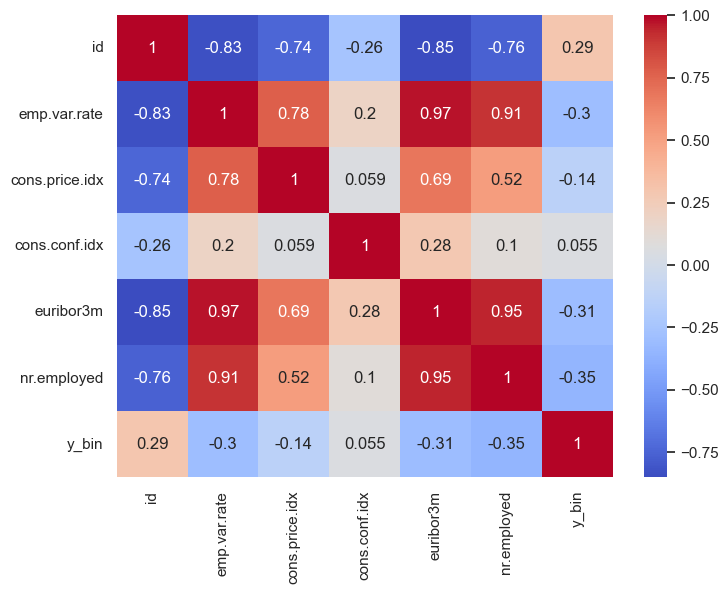

In [30]:

# 7. Corrélation macro-économie vs acceptation
plt.figure(figsize=(8,6))
sns.heatmap(dt[macro_cols + ['y_bin']].corr(), annot=True, cmap="coolwarm")
plt.savefig(OUT_DIR / "Corrélation macro-économie vs acceptation.png", dpi=300, bbox_inches='tight')
plt.show()
